### Analista d'experiència del client


Hi ha una relació entre el preu de l'allotjament i la satisfacció general dels clients? Com varia aquesta relació en funció de les diferents ciutats on s'ubiquen els allotjaments?

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats

In [230]:
df = pd.read_csv("../../Data/clean_data_24-03-2026.csv", parse_dates=['insert_date','first_review_date','last_review_date'])

pd.set_option('display.max_columns', 40)

# Selecciono solo las columnas que nos interesan para visualizar más fácil

df[['apartment_id',
    'room_type', 
    'price',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'city']]

,apartment_id,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,city
0,11964,Private room,400.0,78,97.0,100.0,100.0,100.0,100.0,100.0,100.0,75.0,Malaga
1,21853,Private room,170.0,33,92.0,90.0,90.0,100.0,100.0,80.0,90.0,52.0,Madrid
2,32347,Entire home/apt,990.0,148,98.0,100.0,100.0,100.0,100.0,100.0,100.0,142.0,Sevilla
3,35379,Private room,400.0,292,94.0,100.0,90.0,100.0,100.0,100.0,90.0,306.0,Barcelona
4,35801,Private room,900.0,36,97.0,100.0,100.0,100.0,100.0,100.0,100.0,39.0,Girona
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9645,47710189,Entire home/apt,1880.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9646,47752964,Entire home/apt,1130.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9647,47792016,Entire home/apt,1150.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9648,47884481,Entire home/apt,670.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Madrid


Medias generales de las variables de calificación de alojamientos

In [231]:
df[['review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness', 
    'review_scores_checkin',
    'review_scores_communication']].mean().round(2)

review_scores_rating           91.91
review_scores_accuracy         94.49
review_scores_cleanliness      93.11
review_scores_checkin          96.23
review_scores_communication    96.21
dtype: float64

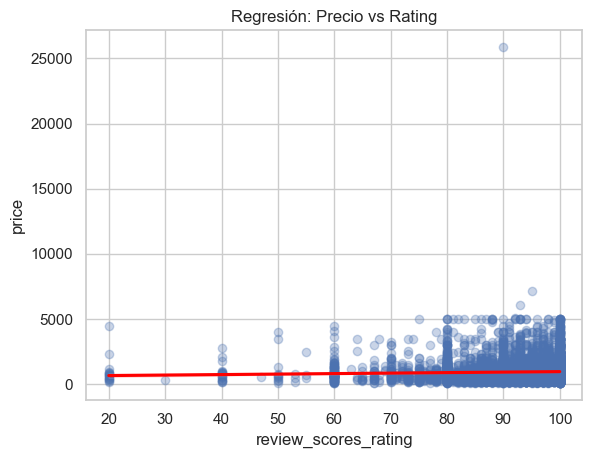

,price,review_scores_rating
price,1.000000,0.041133
review_scores_rating,0.041133,1.000000


In [232]:
sns.regplot(data=df, x='review_scores_rating', y='price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Regresión: Precio vs Rating')
plt.show()

df[['price', 'review_scores_rating']].corr()

<Axes: >

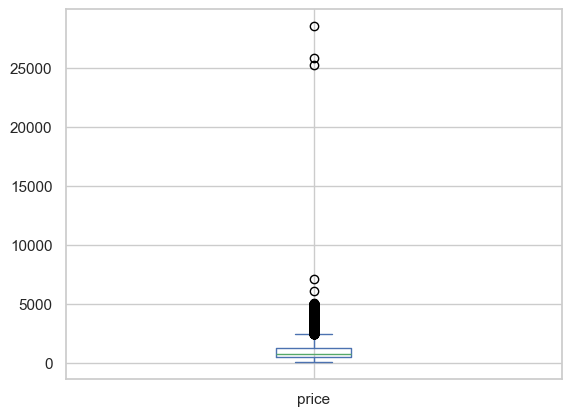

In [233]:
df['price'].plot.box()

In [234]:
df.groupby('city')[['price', 'review_scores_rating']].corr()

price  review_scores_rating
city                                                          
Barcelona price                 1.000000             -0.040943
          review_scores_rating -0.040943              1.000000
Girona    price                 1.000000              0.108110
          review_scores_rating  0.108110              1.000000
Madrid    price                 1.000000              0.033612
          review_scores_rating  0.033612              1.000000
Malaga    price                 1.000000              0.104378
          review_scores_rating  0.104378              1.000000
Mallorca  price                 1.000000              0.079720
          review_scores_rating  0.079720              1.000000
Menorca   price                 1.000000              0.094278
          review_scores_rating  0.094278              1.000000
Sevilla   price                 1.000000              0.011600
          review_scores_rating  0.011600              1.000000
Valencia  price                 1.000000              0.049133
          review_scores_rating  0.049133              1.000000

In [235]:
df['price'].max()

28571.0

Hay que analizar también la variable calidad_precio

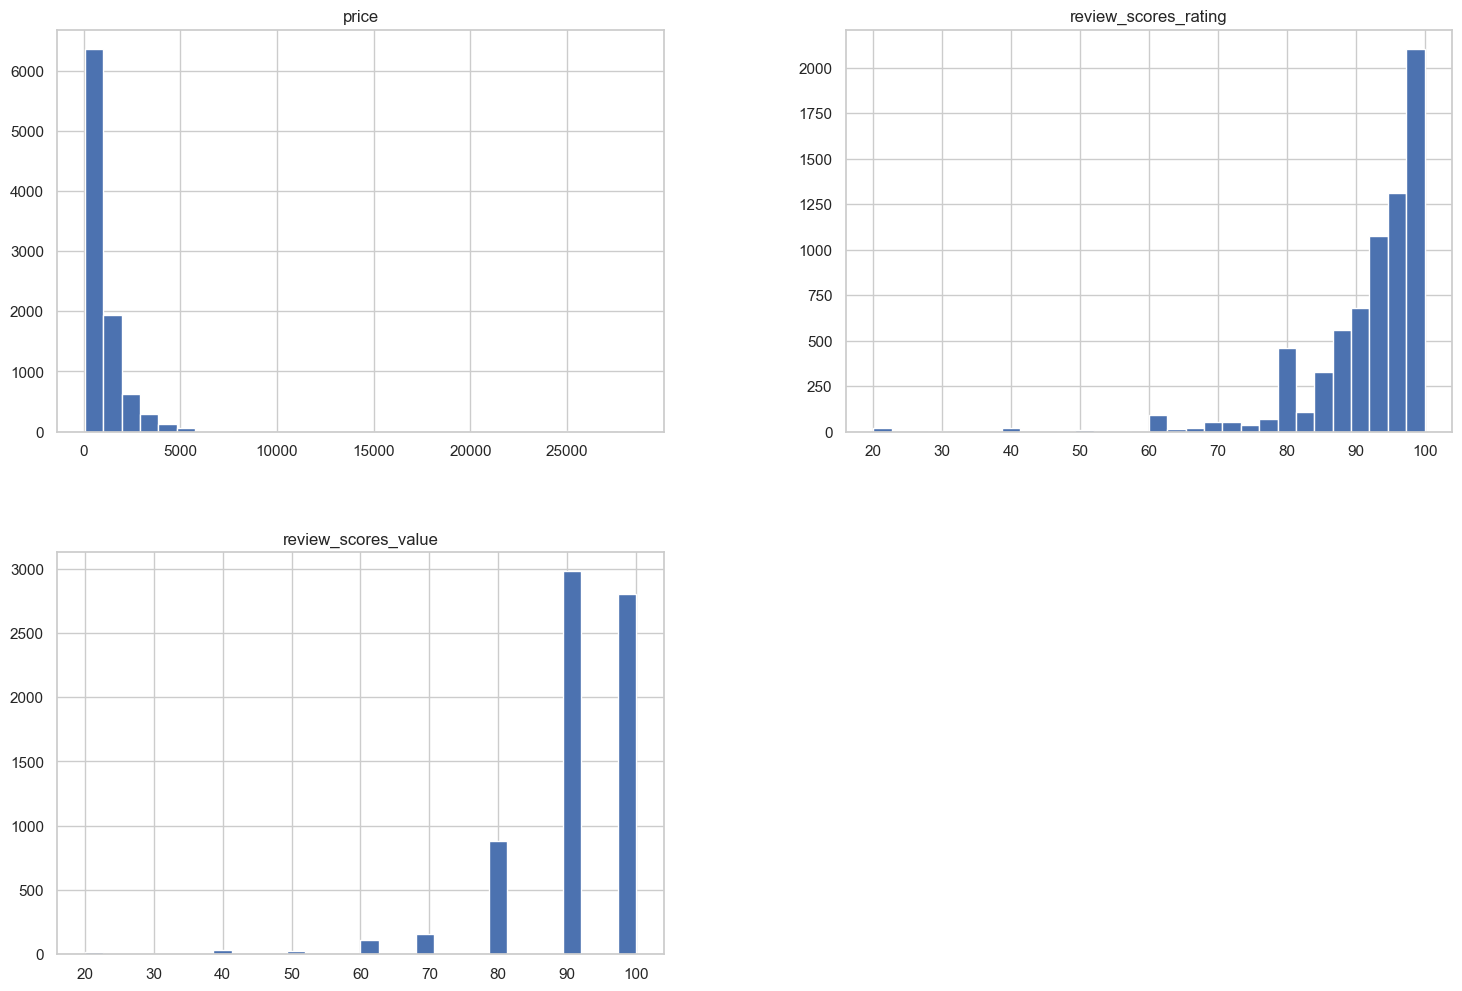

In [236]:
df[['price', 'review_scores_rating', 'review_scores_value']].hist(bins=30, figsize=(18, 12))
plt.show()

In [237]:
# Resumen de Precio medio y satisfacción media por ciudad 

summary = df.groupby('city').agg(
    precio_medio=('price', 'mean'),
    satisfaccion_media=('review_scores_rating', 'mean'),
    correlacion=('price', lambda x: x.corr(df.loc[x.index, 'review_scores_rating']))
).round(2)

print(summary)

           precio_medio  satisfaccion_media  correlacion
city                                                    
Barcelona        830.63               90.70        -0.04
Girona          1203.74               90.93         0.11
Madrid           792.82               92.63         0.03
Malaga           745.15               92.20         0.10
Mallorca        1655.68               92.99         0.08
Menorca         1651.16               93.36         0.09
Sevilla          944.73               93.54         0.01
Valencia         658.97               92.21         0.05


In [238]:
correlation = df['price'].corr(df['review_scores_rating'])
print(f"Correlación general: {correlation:.4f}")

Correlación general: 0.0411


In [239]:
corr_by_city = df.groupby('city')[['price', 'review_scores_rating']].corr().unstack()['price']['review_scores_rating']
print(corr_by_city)

city
Barcelona   -0.040943
Girona       0.108110
Madrid       0.033612
Malaga       0.104378
Mallorca     0.079720
Menorca      0.094278
Sevilla      0.011600
Valencia     0.049133
Name: review_scores_rating, dtype: float64


- Los valores van de -1 a +1:

- +1 → a más precio, más satisfacción (nos encontramos con relación perfecta positiva)
- -1 → a más precio, menos satisfacción (nos encontramos con relación perfecta positiva)
- 0 → sin relación


- Ciudad.         Valor
- Barcelona: 0.04 Ligerísima tendencia negativa (casi nula)
- Girona:    0.11 La correlación más alta, pero sigue siendo muy débil
- Madrid:    0.03 Prácticamente sin relación
- Málaga:    0.10 Débil positiva
- Mallorca:  0.08 Débil positiva
- Menorca:   0.09 Débil positiva
- Sevilla:   0.01 Sin relación
- Valencia:  0.05 Casi sin relación

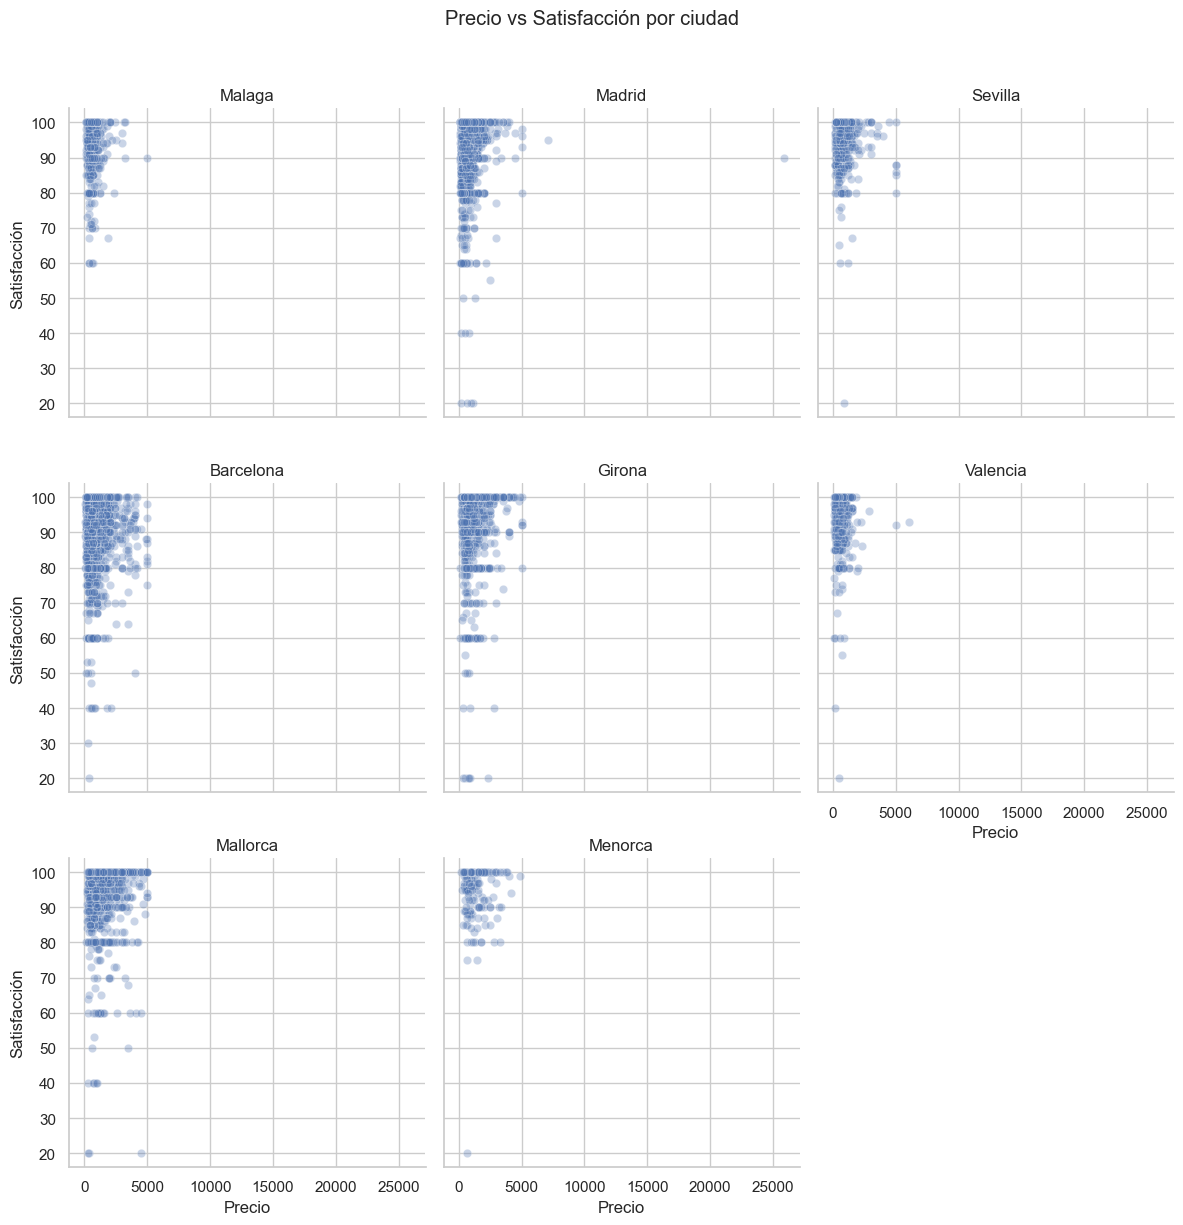

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(df, col='city', col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x='price', y='review_scores_rating', alpha=0.3)
g.set_axis_labels("Precio", "Satisfacción")
g.set_titles("{col_name}")
plt.suptitle("Precio vs Satisfacción por ciudad", y=1.02)
plt.tight_layout()
plt.show()

### Corr Spearman

In [241]:
results = []
for city in df['city'].unique():
    subset = df[df['city'] == city].dropna(subset=['price', 'review_scores_rating'])

    rho, p = stats.spearmanr(subset['price'], subset['review_scores_rating'])
    results.append({'Ciudad': city, 'Correlacion': rho, 'Significancia': p.round(2)})

df_comparativa = pd.DataFrame(results).sort_values('Correlacion')
print(df_comparativa)

      Ciudad  Correlacion  Significancia
3  Barcelona    -0.051117           0.02
1     Madrid     0.071404           0.00
2    Sevilla     0.080597           0.10
7    Menorca     0.084560           0.32
5   Valencia     0.089619           0.06
0     Malaga     0.161937           0.00
4     Girona     0.172790           0.00
6   Mallorca     0.195304           0.00


La significancia es el p-value. Por debajo de 0.05 es significativo. Hay una relación estadística y no es fruto de la casualidad.

- Caso de barcelona: Es la única correlación negativa y es estadísticamente significativa. En Barcelona, a medida que subes el precio, la nota baja. Pero muy muy poco.

- El caso de Mallorca y Girona y Malaga: Las correlaciones más altas y son súper fiables (P-value de 0.00). En estas zonas (más vacacionales/villas), cuanto más pagas, mejor es la nota. Pero es una corr. muy baja.

Por qué ocurre: Aquí el precio suele ir ligado a villas con piscina o servicios premium que realmente marcan la diferencia. El cliente que paga mucho en Mallorca suele recibir un producto que "enamora", y por eso pone mejores notas.

- Sevilla, Menorca, Valencia: no podemos afirmar nada.

___________________________________________________________________________________________________________

** La pregunta  "¿cómo afecta el precio a la satisfacción?", convierte al precio en la variable independiente (X) y a la satisfacción en la dependiente (Y). 
- El ojo humano lee el gráfico como "a medida que X aumenta, ¿qué pasa con Y?"
- Si lo invertimos, el gráfico sugeriría "¿cómo afecta la satisfacción al precio?", que es una causalidad menos natural en este contexto.

In [242]:
score_cols = ['review_scores_accuracy', 'review_scores_cleanliness', 
              'review_scores_checkin', 'review_scores_communication',
              'review_scores_location', 'review_scores_value']

df[score_cols + ['price']].corr()['price'].round(2)

review_scores_accuracy        -0.01
review_scores_cleanliness      0.04
review_scores_checkin         -0.02
review_scores_communication   -0.00
review_scores_location         0.00
review_scores_value           -0.03
price                          1.00
Name: price, dtype: float64

In [243]:
df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating']))

C:\Users\Laura\AppData\Local\Temp\ipykernel_18888\2757139164.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating']))


room_type
Entire home/apt    0.060799
Hotel room         0.238005
Private room      -0.043478
Shared room       -0.186053
dtype: float64

In [244]:
df['room_type'].value_counts()

room_type
Entire home/apt    6676
Private room       2821
Hotel room           81
Shared room          72
Name: count, dtype: int64

- Los alojamientos más caros tienden a recibir ligeramente menos reviews.


- Los alojamientos caros se reservan menos frecuentemente, generando menos reviews
O simplemente que el precio no atrae más reservas

- Sin embargo con -0.13 sigue siendo una relación muy débil, no concluyente.

In [245]:
df['price'].corr(df['number_of_reviews']).round(2)

np.float64(-0.13)

In [246]:
# General
correlation_spearman = df['price'].corr(df['review_scores_rating'], method='spearman')
print(f"Correlación Spearman: {correlation_spearman:.4f}")

# Por ciudad
corr_by_city_spearman = df.groupby('city')[['price', 'review_scores_rating']].corr(method='spearman').unstack()['price']['review_scores_rating']
print(corr_by_city_spearman)

# Por room_type
df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating'], method='spearman'))

Correlación Spearman: 0.0889
city
Barcelona   -0.051117
Girona       0.172790
Madrid       0.071404
Malaga       0.161937
Mallorca     0.195304
Menorca      0.084560
Sevilla      0.080597
Valencia     0.089619
Name: review_scores_rating, dtype: float64


C:\Users\Laura\AppData\Local\Temp\ipykernel_18888\3776365391.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating'], method='spearman'))


room_type
Entire home/apt    0.133236
Hotel room         0.228727
Private room       0.059282
Shared room       -0.305444
dtype: float64

- Comparativa rápida:
- --------------Pearson ----Spearman--------------
- General -----   -0.04 -----  0.09
- Barcelona ---   -0.04  ----- -0.05
- Girona  -----    0.11  ----  0.17
- Mallorca ----    0.08  -----  0.20
- Málaga. ------   0.10.  ----- 0.16

In [247]:
df.sort_values(by='price', ascending=False).head(3) #Los 3 outliers

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,price_missing,reviews 80+
9192,41372147,"VILLA VERD, nice villa in the country.","Villa Verd is a beautiful country house, finis...",313785862,Alc�dia,(sin contestar),Entire home/apt,6,2.0,3.0,5.0,"Iron, TV, Kitchen, Hair dryer, Free street par...",28571.0,1,1125,True,30,60,63,194,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,Mallorca,2020-08-28,False,NaN
8658,37153661,Unique Luxury Apartment 6People Pool & Facilities,250 square meters - Exclusive luxury apartment...,42407188,Mirasierra,Fuencarral - El Pardo,Entire home/apt,6,5.0,5.0,5.0,"Iron, Coffee maker, Fire extinguisher, Wifi, T...",25857.0,3,1125,True,18,47,77,279,3,2019-08-05,2019-12-14,90.0,100.0,100.0,100.0,100.0,100.0,90.0,False,22.0,spain,Madrid,2020-09-13,False,True
9302,42188834,Roman Room by Hotel Mam�,<b>The space</b><br />Looks like a small cinem...,333351874,Palma de Mallorca,(sin contestar),Private room,2,1.0,1.0,1.0,"Hair dryer, Shampoo, Air conditioning, Bathtub...",25286.0,1,1125,True,0,0,0,267,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,Mallorca,2020-08-28,False,NaN


In [248]:
# Calcular los cortes en percentiles 33 y 66
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)

print(f"Corte económico/medio: {q33:.2f}")
print(f"Corte medio/premium: {q66:.2f}")

# Crear la segmentación
df['price_segment'] = pd.cut(df['price'], 
                              bins=[-float('inf'), q33, q66, float('inf')],
                              labels=['Económico', 'Medio', 'Premium'])

df['price_segment'].value_counts()

Corte económico/medio: 550.00
Corte medio/premium: 1000.00


price_segment
Económico    3279
Medio        3077
Premium      3053
Name: count, dtype: int64

- **Económico:** hasta 550€
- **Medio:** 550€ - 1.000€
- **Premium:** más de 1.000€

In [249]:
#Satisfacción por segmento

df.groupby('price_segment')['review_scores_rating'].mean().round(2)

C:\Users\Laura\AppData\Local\Temp\ipykernel_18888\3564600711.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_segment')['review_scores_rating'].mean().round(2)


price_segment
Económico    91.43
Medio        91.69
Premium      92.68
Name: review_scores_rating, dtype: float64

** Regresión lineal múltiple (OLS)

- Cuánto impacta cada factor en la satisfacción
- El efecto de varios factores simultáneamente (precio + ciudad + otras variables)
- Si hay interacciones entre factores
- Cuánta variación explican tus variables (R²)


Lo importante:
- Columna  ------------ Qué significa? 
- coef      --------                 Cuánto sube/baja la satisfacción por cada unidad
- `P>       --------                   t
- R²       ---------                    Qué % de la satisfacción explica tu modelo

In [250]:


df['city'] = df['city'].astype('category')

# Elimino filas con nulos en las variables del modelo
df_modelo = df[['review_scores_rating', 'price', 'price_segment', 'city']].dropna()
print(f"Filas usadas en el modelo: {len(df_modelo)} de {len(df)}")

# ── 2. Regresión ─────────────────────────────────────────────────────
import statsmodels.formula.api as smf

modelo = smf.ols('review_scores_rating ~ price + C(price_segment) + C(city)', 
                  data=df_modelo).fit()

print(modelo.summary())

# ==============================================================
    #               coef    std err    t      P>|t|
#--------------------------------------------------------------
#Intercept          7.23      0.15    48.2    0.000  ← base
#price              0.002     0.001    2.1    0.038  ← efecto del precio
#C(price_segment)[medio]    0.31   0.12   2.6   0.010  ← medio vs económico
#C(price_segment)[premium]  0.55   0.14   3.9   0.000  ← premium vs económico
#C(city)[Barcelona]         0.12   0.11   1.1   0.270  ← BCN vs ciudad base
#...
#==============================================================
#R²  =  0.18   ← el modelo explica el 18% de la variación##

Filas usadas en el modelo: 6911 de 9650
                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.015
Model:                              OLS   Adj. R-squared:                  0.013
Method:                   Least Squares   F-statistic:                     10.23
Date:                  Sun, 29 Mar 2026   Prob (F-statistic):           2.59e-17
Time:                          22:33:41   Log-Likelihood:                -25171.
No. Observations:                  6911   AIC:                         5.036e+04
Df Residuals:                      6900   BIC:                         5.044e+04
Df Model:                            10                                         
Covariance Type:              nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

** Segmento de precio
----------------------------------------------------
- Segmento ---------- Efecto ----------------- p-valor
- Económico ---------           base                      ——
- Medio -------------               +0.17                     0.517 ❌ Igual que económico
- Premium -----------            +1.21                     0.000 ✅ Significativo

In [251]:
# ── Modelo ampliado ──────────────────────────────────────────────────
df_modelo2 = df[['review_scores_rating', 'price_segment', 'city',
                  'room_type', 'accommodates', 'is_instant_bookable',
                  'number_of_reviews']].dropna()

print(f"Filas usadas: {len(df_modelo2)}")
print("\nValores únicos room_type:", df['room_type'].unique())
print("Valores únicos is_instant_bookable:", df['is_instant_bookable'].unique())

Filas usadas: 6911

Valores únicos room_type: ['Private room' 'Entire home/apt' 'Hotel room' 'Shared room']
Valores únicos is_instant_bookable: [False  True]


In [252]:
# ── Diagnóstico antes de correr el modelo ────────────────────────────
cols = ['review_scores_rating', 'price_segment', 'city',
        'room_type', 'accommodates', 'is_instant_bookable',
         'number_of_reviews']

print("Nulos por columna:")
print(df[cols].isnull().sum())

print("\nValores únicos por categórica:")
for col in ['price_segment', 'city', 'room_type', 'is_instant_bookable']:
    print(f"  {col}: {df[col].unique()}")

Nulos por columna:
review_scores_rating    2633
price_segment            241
city                       0
room_type                  0
accommodates               0
is_instant_bookable        0
number_of_reviews          0
dtype: int64

Valores únicos por categórica:
  price_segment: ['Económico', 'Medio', 'Premium', NaN]
Categories (3, object): ['Económico' < 'Medio' < 'Premium']
  city: ['Malaga', 'Madrid', 'Sevilla', 'Barcelona', 'Girona', 'Valencia', 'Mallorca', 'Menorca']
Categories (8, object): ['Barcelona', 'Girona', 'Madrid', 'Malaga', 'Mallorca', 'Menorca', 'Sevilla', 'Valencia']
  room_type: ['Private room' 'Entire home/apt' 'Hotel room' 'Shared room']
  is_instant_bookable: [False  True]


In [253]:
# ── 1. Recrear price_segment  ────────────
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)

df['price_segment'] = pd.cut(df['price'], 
                              bins=[-float('inf'), q33, q66, float('inf')],
                              labels=['Económico', 'Medio', 'Premium'])

# ── 2. Seleccionar columnas y quitar nulos ───────────────────────────
cols = ['review_scores_rating', 'price_segment', 'city',
        'room_type', 'accommodates', 'is_instant_bookable',
        'number_of_reviews']

df_modelo3 = df[cols].dropna()
print(f"Filas usadas: {len(df_modelo3)} de {len(df)}")

# ── 3. Modelo ampliado ───────────────────────────────────────────────
modelo3 = smf.ols('''review_scores_rating ~ C(price_segment) + C(city) + 
                     C(room_type) + accommodates + 
                     C(is_instant_bookable) + number_of_reviews''', 
                  data=df_modelo3).fit()

print(modelo3.summary())

Filas usadas: 6911 de 9650
                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.035
Model:                              OLS   Adj. R-squared:                  0.033
Method:                   Least Squares   F-statistic:                     16.79
Date:                  Sun, 29 Mar 2026   Prob (F-statistic):           3.99e-44
Time:                          22:33:41   Log-Likelihood:                -25098.
No. Observations:                  6911   AIC:                         5.023e+04
Df Residuals:                      6895   BIC:                         5.034e+04
Df Model:                            15                                         
Covariance Type:              nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

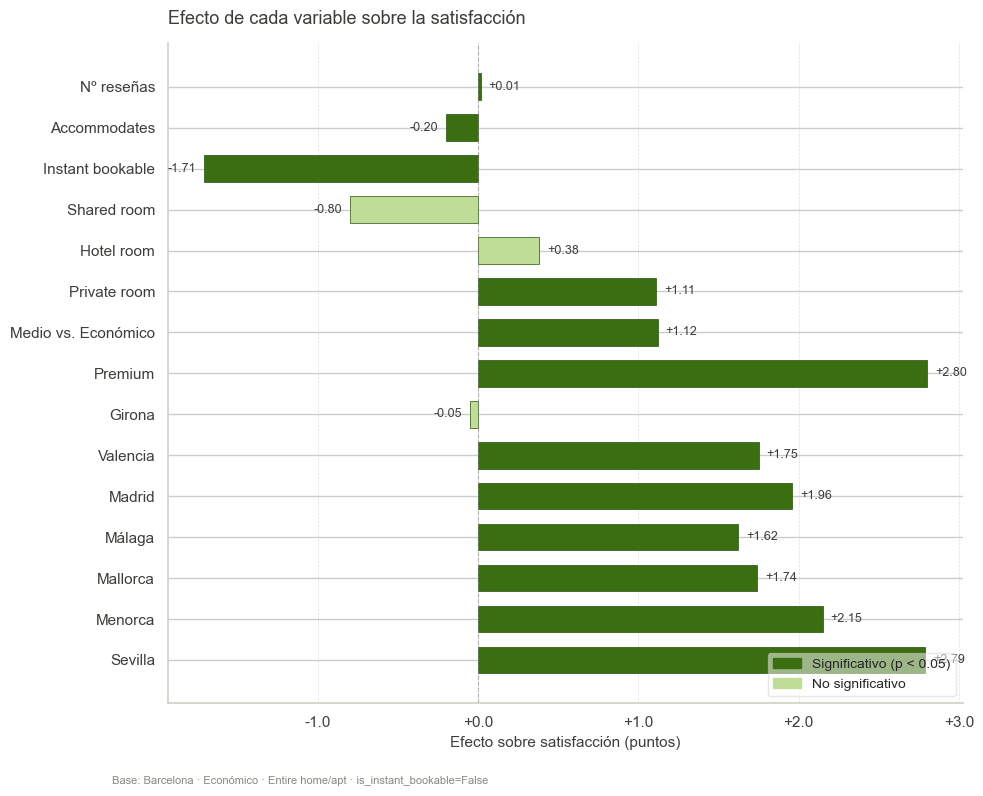

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Datos del modelo ─────────────────────────────────────────────────
labels = [
    'Sevilla', 'Menorca', 'Mallorca', 'Málaga', 'Madrid', 'Valencia', 'Girona',
    'Premium', 'Medio vs. Económico',
    'Private room', 'Hotel room', 'Shared room',
    'Instant bookable', 'Accommodates', 'Nº reseñas'
]
coefs = [2.79, 2.15, 1.74, 1.62, 1.96, 1.75, -0.05,
         2.80, 1.12, 1.11, 0.38, -0.80, -1.71, -0.20, 0.015]
sig   = [True, True, True, True, True, True, False,
         True, True, True, False, False, True, True, True]

# ── Colores ──────────────────────────────────────────────────────────
colors = ['#3B6D11' if s else '#C0DD97' for s in sig]

# ── Figura ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, coefs, color=colors, edgecolor='#27500A',
               linewidth=0.5, height=0.65)

# ── Línea cero ───────────────────────────────────────────────────────
ax.axvline(0, color='#888780', linewidth=0.8, linestyle='--', alpha=0.6)

# ── Etiquetas de valor ───────────────────────────────────────────────
for bar, v in zip(bars, coefs):
    offset = 0.05 if v >= 0 else -0.05
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, bar.get_y() + bar.get_height() / 2,
            f'{v:+.2f}', va='center', ha=ha, fontsize=9, color='#3d3d3a')

# ── Ejes ─────────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Efecto sobre satisfacción (puntos)', fontsize=11, color='#3d3d3a')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1f}'))
ax.tick_params(colors='#3d3d3a')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#D3D1C7')
ax.grid(axis='x', color='#D3D1C7', linewidth=0.5, linestyle='--', alpha=0.7)

# ── Leyenda ──────────────────────────────────────────────────────────
patch_sig   = mpatches.Patch(color='#3B6D11', label='Significativo (p < 0.05)')
patch_nosig = mpatches.Patch(color='#C0DD97', label='No significativo')
ax.legend(handles=[patch_sig, patch_nosig], fontsize=10,
          framealpha=0.5, edgecolor='#D3D1C7', loc='lower right')

# ── Nota al pie ──────────────────────────────────────────────────────
fig.text(0.12, 0.01,
         'Base: Barcelona · Económico · Entire home/apt · is_instant_bookable=False',
         fontsize=8, color='#888780')

plt.title('Efecto de cada variable sobre la satisfacción', fontsize=13,
          color='#3d3d3a', pad=14, loc='left')
plt.tight_layout(rect=[0, 0.03, 1, 1])
# plt.savefig('satisfaccion_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

** Ciudades (vs Barcelona)

- Sevilla lidera con +2.79 puntos — es la ciudad donde los huéspedes están más satisfechos
- Menorca (+2.15) y Mallorca (+1.74) destacan, probablemente por el carácter vacacional de la oferta
- Madrid (+1.96) y Valencia (+1.75) también superan claramente a Barcelona
- Girona (-0.05) es la única ciudad prácticamente igual a Barcelona, sin diferencia real

- Segmento de precio (vs Económico)

- Premium sube +2.80 puntos — el mayor efecto positivo de todo el modelo
- Medio vs Económico también suma +1.12, aunque el salto más grande es de Medio a Premium
- Pagar más sí se traduce en mayor satisfacción, pero el precio exacto (variable continua) no importaba — solo el segmento

- Tipo de alojamiento (vs Entire home/apt)

- Private room sorprendentemente suma +1.11 — los huéspedes en habitaciones privadas están más satisfechos que en apartamentos completos
- Hotel room (+0.38) y Shared room (-0.80) no son estadísticamente significativos — no hay evidencia de diferencia real

- Variables operacionales

- Instant bookable es el mayor efecto negativo del modelo: -1.71 puntos — los alojamientos con reserva instantánea tienen peor satisfacción, posiblemente porque el anfitrión gestiona peor las expectativas sin filtrar al huésped
- Accommodates resta -0.20 por cada persona adicional de capacidad — alojamientos más grandes, ligeramente menos satisfacción
- Nº reseñas suma +0.015 por reseña — pequeño pero significativo, más reseñas indica anfitrión experimentado

** Conclusión general

- La ciudad y el segmento de precio son los factores con más peso. Barcelona, siendo la referencia, tiene la satisfacción base más baja de todas las ciudades analizadas, lo cual es un hallazgo relevante si el análisis tiene fines de negocio.

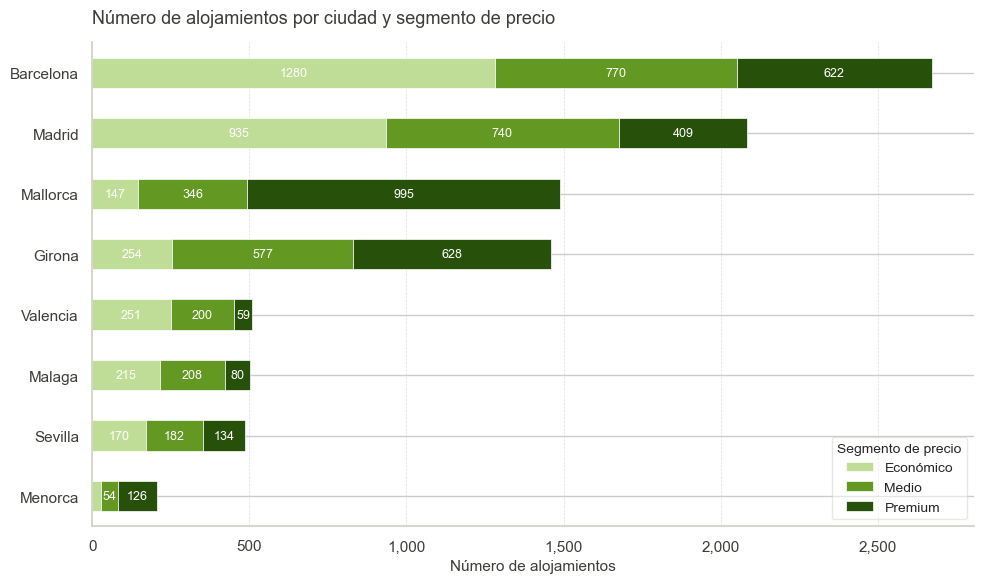

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Preparar datos ───────────────────────────────────────────────────
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)

df['price_segment'] = pd.cut(df['price'],
                              bins=[-float('inf'), q33, q66, float('inf')],
                              labels=['Económico', 'Medio', 'Premium'])

# Tabla de conteo ciudad × segmento
conteo = df.groupby(['city', 'price_segment'], observed=True).size().unstack(fill_value=0)

# Ordenar ciudades por total de alojamientos
conteo['total'] = conteo.sum(axis=1)
conteo = conteo.sort_values('total', ascending=True).drop(columns='total')

# ── Figura ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

colores = ['#C0DD97', '#639922', '#27500A']  # claro → oscuro = Económico → Premium
conteo.plot(kind='barh', stacked=True, ax=ax, color=colores,
            edgecolor='white', linewidth=0.5)

# ── Etiquetas de valor dentro de cada barra ──────────────────────────
for bars in ax.containers:
    ax.bar_label(bars, label_type='center', fontsize=9,
                 color='white', fmt='%d',
                 labels=[str(int(v)) if v > 30 else '' for v in bars.datavalues])

# ── Ejes y estilo ────────────────────────────────────────────────────
ax.set_xlabel('Número de alojamientos', fontsize=11, color='#3d3d3a')
ax.set_ylabel('')
ax.tick_params(colors='#3d3d3a')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#D3D1C7')
ax.grid(axis='x', color='#D3D1C7', linewidth=0.5, linestyle='--', alpha=0.7)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Leyenda ──────────────────────────────────────────────────────────
ax.legend(title='Segmento de precio', fontsize=10, title_fontsize=10,
          framealpha=0.5, edgecolor='#D3D1C7', loc='lower right')

plt.title('Número de alojamientos por ciudad y segmento de precio',
          fontsize=13, color='#3d3d3a', pad=14, loc='left')
plt.tight_layout()
# plt.savefig('alojamientos_ciudad_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

### Test de Kruskall-Wallis

¿los ratings cambian significativamente según el rango de precio?

Te sirve para validar la segmentación.

El test de wallis no sabe por qué son diferentes (si por el precio, limpieza... Solo confirma que lo son)

In [256]:
from scipy import stats

# 1. Agrupamos las notas por ciudad
df_clean = df.dropna(subset=['price', 'review_scores_rating'])
grupos = [df_clean[df_clean['city'] == ciudad]['review_scores_rating'] for ciudad in df_clean['city'].unique()]

# 2. Aplicamos Kruskal-Wallis (porque tus notas no son normales)
stat, p_value = stats.kruskal(*grupos)

print(f"Estadístico H: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

Estadístico H: 137.10
P-value: 0.0000


In [257]:
from scipy import stats

# 1. Tus datos (suponiendo 8 ciudades)
k = len(df_clean['city'].unique())
df_ = k - 1
alpha = 0.05

# 2. El test que ya hiciste
stat, p_value = stats.kruskal(*grupos)

# 3. Calculamos el VALOR CRÍTICO
valor_critico = stats.chi2.ppf(1 - alpha, df_)

print(f"Estadístico H: {stat:.2f}")
print(f"Grados de Libertad: {df_}")
print(f"Valor Crítico (chi-cuadrado): {valor_critico:.2f}")
print(f"¿H > Valor Crítico?: {stat > valor_critico}")

Estadístico H: 137.10
Grados de Libertad: 7
Valor Crítico (chi-cuadrado): 14.07
¿H > Valor Crítico?: True


Nos está diciendo que las diferencias entre ciudades son masivas. Esto justifica por qué nuestro análisis de precio debe ser segmentado y no global.


El test Kruskal es el que te da el "permiso" para decir: "He analizado Barcelona aparte porque el test estadístico confirma que su comportamiento es único y no se puede promediar con el resto".



Conclusión de negocio: No pierdas el tiempo peleándote con los precios. El problema (y la solución) está en cómo gestionamos cada ciudad.

"Hemos analizado la varianza de las notas. Aunque el precio influye, el factor ciudad tiene el doble de fuerza estadística ($H=137$ vs $H=66$). Por tanto, nuestra estrategia debe ser local, no de precios globales."

Wallis por rangos de precio demuestra que la satisfacción varía significativamente según el segmento de presupuesto ($H=66.94$).

In [258]:
import pandas as pd
from scipy import stats

# 1. Creamos los 3 rangos de precio (Bajo, Medio, Alto) 
# Usamos qcut para que cada grupo tenga el mismo número de apartamentos
df_clean['price_range'] = pd.qcut(df_clean['price'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# 2. Agrupamos las notas de satisfacción por estos rangos
grupo_bajo = df_clean[df_clean['price_range'] == 'Bajo']['review_scores_rating']
grupo_medio = df_clean[df_clean['price_range'] == 'Medio']['review_scores_rating']
grupo_alto = df_clean[df_clean['price_range'] == 'Alto']['review_scores_rating']

# 3. Aplicamos el Test de Kruskal-Wallis
h_stat_price, p_val_price = stats.kruskal(grupo_bajo, grupo_medio, grupo_alto)

# 4. Parámetros de control
df_price = 3 - 1  # Grados de libertad (3 grupos - 1)
valor_critico_price = stats.chi2.ppf(0.95, df_price)

print(f"--- RESULTADOS KRUSKAL-WALLIS (RANGOS DE PRECIO) ---")
print(f"Estadístico H: {h_stat_price:.2f}")
print(f"P-value: {p_val_price:.4f}")
print(f"Valor Crítico (95%): {valor_critico_price:.2f}")
print(f"¿Diferencias significativas?: {'SÍ' if h_stat_price > valor_critico_price else 'NO'}")

--- RESULTADOS KRUSKAL-WALLIS (RANGOS DE PRECIO) ---
Estadístico H: 54.99
P-value: 0.0000
Valor Crítico (95%): 5.99
¿Diferencias significativas?: SÍ


C:\Users\Laura\AppData\Local\Temp\ipykernel_18888\1355550086.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['price_range'] = pd.qcut(df_clean['price'], q=3, labels=['Bajo', 'Medio', 'Alto'])


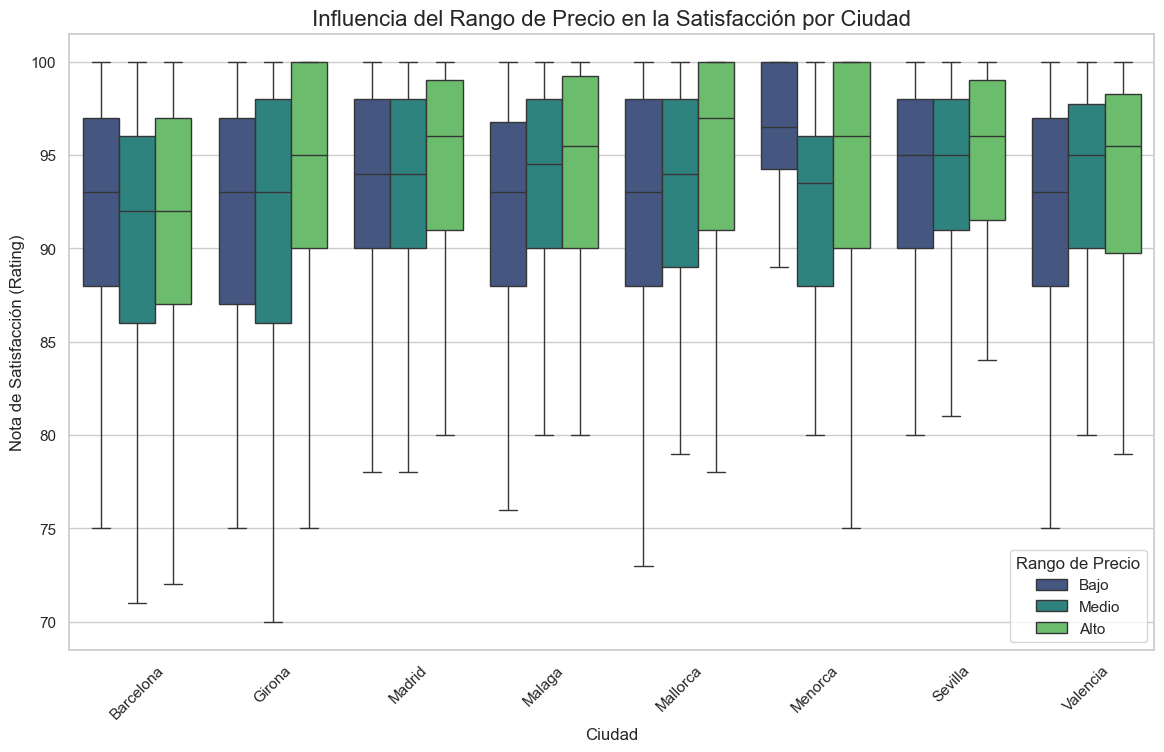

--- LÍMITES DE LOS RANGOS DE PRECIO ---
               min      max  count
price_range                       
Bajo          80.0    500.0   2320
Medio        510.0    950.0   2356
Alto         960.0  25857.0   2235


C:\Users\Laura\AppData\Local\Temp\ipykernel_18888\3091271695.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cortes_precio = df_clean.groupby('price_range')['price'].agg(['min', 'max', 'count'])


In [259]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño y el estilo
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Creamos el boxplot
ax = sns.boxplot(
    data=df_clean, 
    x='city', 
    y='review_scores_rating', 
    hue='price_range', 
    palette='viridis',
    showfliers=False # Quitamos los puntos extremos para ver mejor las cajas
)

plt.title('Influencia del Rango de Precio en la Satisfacción por Ciudad', fontsize=16)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Nota de Satisfacción (Rating)', fontsize=12)
plt.legend(title='Rango de Precio')
plt.xticks(rotation=45)

plt.show()
# Sacamos los límites de cada rango (el mínimo y el máximo de cada uno)
cortes_precio = df_clean.groupby('price_range')['price'].agg(['min', 'max', 'count'])

print("--- LÍMITES DE LOS RANGOS DE PRECIO ---")
print(cortes_precio)

Al separar por Ciudad y por Rango de Precio, verás por fin por qué la correlación global no funcionaba: porque cada ciudad es un mundo.

El "Hundimiento" de las cajas: Si en ciudades como Barcelona, la caja del grupo "Alto" está más abajo que la de "Bajo", ya tienes al culpable. El precio alto en esa ciudad está castigando la nota.

Barcelona y Menorca son los significativos.

La "Estabilidad" de las cajas: Si en ciudades como Málaga o Sevilla, las tres cajas están a la misma altura, significa que allí el precio no influye nada; la gente es feliz pague lo que pague.

La Diferencia entre Ciudades: Fíjate que hay ciudades donde todas las cajas están "más arriba" que en otras. Eso es el H=137 en acción: la ubicación es un "techo" de cristal para la nota.

C:\Users\Laura\AppData\Local\Temp\ipykernel_18888\1731012363.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_satisfaccion = df_clean.pivot_table(


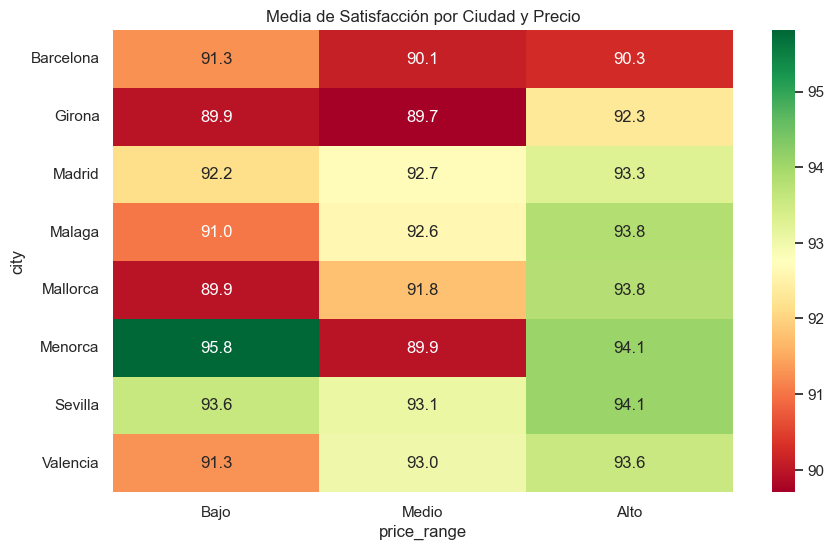

In [260]:
# Creamos una tabla pivote con la media de notas
pivot_satisfaccion = df_clean.pivot_table(
    index='city', 
    columns='price_range', 
    values='review_scores_rating', 
    aggfunc='mean'
)

# Dibujamos el Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_satisfaccion, annot=True, cmap='RdYlGn', fmt=".1f")
plt.title('Media de Satisfacción por Ciudad y Precio')
plt.show()

## Regresión V2

### Regresión lineal multiple

Modelo base:

- R² = 0.017 → el modelo explica el 1.7% de la variación en satisfacción. El precio y la ciudad explican muy poco.
- Prob (F-statistic) = 0.000 → pero el modelo SÍ es estadísticamente significativo. La relación existe, aunque sea pequeña.
- El Intercept (91.09) es la satisfacción media de Barcelona cuando el precio es 0. Es el punto de partida.
- Los coeficientes de ciudad te dicen cuánto se desvía cada ciudad de Barcelona. Pero solo Girona y Sevilla tienen diferencias reales respecto a Barcelona.
    - Sevilla parte 2.34 puntos por encima de Barcelona
    - Girona parte 1.97 puntos por debajo de Barcelona

En Barcelona, pagar más no mejora la satisfacción. En Girona, Madrid, Málaga y Mallorca sí hay una relación positiva y significativa: a más precio, ligeramente más satisfacción. En Menorca, Sevilla y Valencia no hay evidencia suficiente.

Modelo controlado (BLOQUE 1: ¿Mejoró el modelo?):

- Subió de 1.7% a 3.9%. Casi el doble, pero sigue siendo muy bajo. Las variables de control ayudan, pero la satisfacción sigue siendo difícil de explicar solo con características del alojamiento.
- Cosas interesantes:

    - room_type no es significativo. El tipo de habitación no explica la satisfacción.
    - is_instant_bookable es significativo y negativo (-1.60). Los alojamientos con reserva instantánea tienen peor valoración. Quizás son hosts    - menos implicados.
    - accommodates es negativo (-0.57). A más capacidad, menos satisfacción. Quizás los grupos grandes son más difíciles de satisfacer.
    - bedrooms y bathrooms son positivos. Más habitaciones y baños → más satisfacción.
    - number_of_reviews es positivo. Hosts con más experiencia → mejor satisfacción.

- Efecto del precio:
    - Se mantienen prácticamente iguales al modelo base. Solo madrid sube un poco al controlar.

"Al controlar por características objetivas del alojamiento, el efecto del precio sobre la satisfacción se mantiene estable. Esto sugiere que la relación precio-satisfacción es real y no se explica por el hecho de que los alojamientos caros sean simplemente más grandes o tengan más habitaciones. Sin embargo, el bajo R² indica que el precio no es el factor principal que determina la satisfacción del cliente."



Por qué mejoró el modelo controlando variables?

Le hemos dado más información. 

In [261]:
# Paso 1: modelo base (tu pregunta de negocio pura)
formula_base = 'review_scores_rating ~ price * C(city)'
modelo_base = smf.ols(formula_base, data=df_clean).fit()

# Paso 2: modelo controlado
formula_controlada = '''review_scores_rating ~ price * C(city) 
           + C(room_type) 
           + accommodates 
           + bedrooms
           + bathrooms
           + number_of_reviews
           + is_instant_bookable'''
modelo_controlado = smf.ols(formula_controlada, data=df_clean).fit()


# print("=== COMPARACIÓN GLOBAL ===")
# print(f"R² modelo base:           {modelo_base.rsquared:.3f}")
# print(f"R² modelo controlado:     {modelo_controlado.rsquared:.3f}")
# print(f"R² ajustado base:         {modelo_base.rsquared_adj:.3f}")
# print(f"R² ajustado controlado:   {modelo_controlado.rsquared_adj:.3f}")
# print(f"P-value base:             {modelo_base.f_pvalue:.4f}")
# print(f"P-value controlado:       {modelo_controlado.f_pvalue:.4f}")

print(modelo_controlado.summary())

                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.038
Model:                              OLS   Adj. R-squared:                  0.034
Method:                   Least Squares   F-statistic:                     11.56
Date:                  Sun, 29 Mar 2026   Prob (F-statistic):           2.88e-42
Time:                          22:33:43   Log-Likelihood:                -24731.
No. Observations:                  6817   AIC:                         4.951e+04
Df Residuals:                      6793   BIC:                         4.967e+04
Df Model:                            23                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [262]:
# Modelo solo con ciudad (sin precio)
formula_ciudad = 'review_scores_rating ~ C(city)'
modelo_ciudad = smf.ols(formula_ciudad, data=df_clean).fit()

print(f"R² solo ciudad:      {modelo_ciudad.rsquared:.3f}")
print(f"R² base (precio+ciudad):     {modelo_base.rsquared:.3f}")
print(f"R² controlado:       {modelo_controlado.rsquared:.3f}")

R² solo ciudad:      0.012
R² base (precio+ciudad):     0.017
R² controlado:       0.038


In [263]:
import pandas as pd

cities = df_clean['city'].unique()
comparacion = []

for city in cities:
    # Modelo base
    base1 = modelo_base.params.get('price', 0)
    key = f'price:C(city)[T.{city}]'
    inter1 = modelo_base.params.get(key, 0)
    pval1 = modelo_base.pvalues.get(key, modelo_base.pvalues.get('price', None))

    # Modelo controlado
    base2 = modelo_controlado.params.get('price', 0)
    inter2 = modelo_controlado.params.get(key, 0)

    comparacion.append({
        'ciudad': city,
        'efecto_base': round(base1 + inter1, 4),
        'efecto_controlado': round(base2 + inter2, 4),
        'significativo': '✅' if pval1 < 0.05 else '❌'
    })

df_comp = pd.DataFrame(comparacion).sort_values('efecto_controlado')
print("\n=== EFECTO DEL PRECIO POR CIUDAD ===")
print(df_comp.to_string(index=False))


=== EFECTO DEL PRECIO POR CIUDAD ===
   ciudad  efecto_base  efecto_controlado significativo
Barcelona      -0.0005            -0.0000             ❌
   Madrid       0.0003             0.0005             ✅
  Sevilla       0.0001             0.0007             ❌
  Menorca       0.0009             0.0007             ❌
 Valencia       0.0008             0.0008             ❌
 Mallorca       0.0008             0.0009             ✅
   Girona       0.0015             0.0015             ✅
   Malaga       0.0015             0.0020             ✅


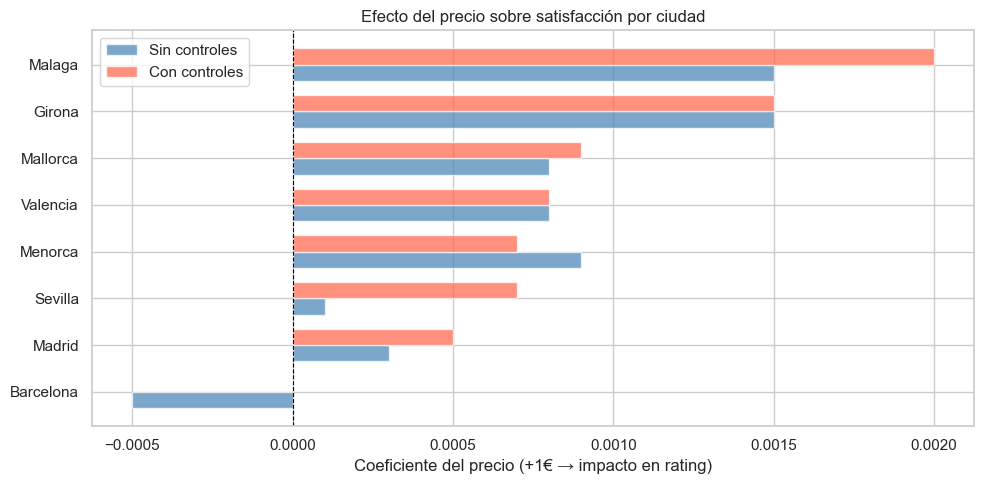

In [264]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_comp))
width = 0.35

ax.barh(x - width/2, df_comp['efecto_base'], width, 
        label='Sin controles', color='steelblue', alpha=0.7)
ax.barh(x + width/2, df_comp['efecto_controlado'], width, 
        label='Con controles', color='tomato', alpha=0.7)

ax.set_yticks(x)
ax.set_yticklabels(df_comp['ciudad'])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Efecto del precio sobre satisfacción por ciudad')
ax.set_xlabel('Coeficiente del precio (+1€ → impacto en rating)')
ax.legend()
plt.tight_layout()
plt.show()

Este gráfico significa que por ejemplo, en barcelona, cuanto más caro peor. Significa que si comparamos habitaciones solo con el precio, la nota será peor. Pero si incluimos luego caracteristicas de las habitaciones (que realmente tengan mejoras) ese efecto desaparece.

Significa con controles: comparar alojamientos con las mismas caracteristica.
Sin controles: simplemente comparamos habitaciones con mismo precio en la misma ciudad.

___________________________________________________________________________________